# GPS Reliability & Route Execution Analysis — v6

Two independent scoring layers:

| Layer | Question | Output |
|-------|----------|--------|
| **GPS Reliability** | Can we trust this data? | `gps_reliability_score` (0–100) + `gps_reliability_tier` |
| **Execution Performance** | Did the vehicle execute the route? | `execution_score` (0–100) or `'insufficient_data'` |

### GPS Reliability — Decision Tree (5 layers, sequential)

| Layer | Dimension | Logic | Outcome |
|-------|-----------|-------|---------|
| 0 | Temporal Coverage | Hard gate: zero pings | Score 0, **stop** |
| 1 | Temporal Coverage | Hard gate: coverage < threshold | Score 1–45, **stop** |
| 2 | Geofence Termination | Hard gate: GPS-terminated trip | Score 45–55, **stop** |
| 3 | Spatial Consistency | Soft signal: frozen coords or impossible jumps | Score 55–75, continue |
| 4 | Cross-Trip Consistency | Soft signal: outlier vs peer group | Score 75–90, continue |
| — | All passed | No flags fired | Score 90–100 |

Hard gates (layers 1–2) terminate scoring immediately.  
Soft signals (layers 3–4) reduce score within their band but do not terminate.

### Peer group (Layer 4)
All trips sharing the same `route_id + trip_type` form one peer group. IQR-based outlier
detection is then applied within each group.

### Frozen ping definition
A ping is frozen when **both** criteria are met:
1. The coordinate is **exactly identical** to the previous ping within the same trip
2. The freeze episode lasts **> 120 seconds** (excludes normal stop dwell / red lights)
3. The ping is **not within 150 m of any planned stop** (BallTree proximity exclusion —
   excludes legitimate extended dwell at bus stops)

### Execution Performance — only computed when GPS Reliability tier is not 'insufficient'

Three components:
- **Stop completion rate** — completed stops ÷ planned stops
- **On-time rate** — share of completed stops with |completed_diff| ≤ threshold
- **Stop sequence adherence** — share of stops completed in planned order


## 0 — Configuration

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings("ignore")

# ── Data paths ─────────────────────────────────────────────────────────────
DATA_DIR   = "/Users/parulchaudhary/Desktop/SEM 2/Exploratory /Live case/Data/"   # ← update: trailing slash required
OUTPUT_DIR = "./outputs/" # ← update: trailing slash required

# ── Layer 1: Temporal Coverage thresholds ─────────────────────────────────
COVERAGE_HARD_GATE    = 0.20   # coverage_rate below this → Layer 1 triggered (hard stop)
GAP_MULTIPLIER        = 3      # gap is 'large' if > N × polling_interval_s
MIN_LARGE_GAP_COUNT   = 3      # used for within-band score penalty

# ── Layer 2: Geofence Termination ─────────────────────────────────────────
GPS_FAIL_TRIGGERS     = {"no_gps_data", "old_last_point"}

# ── Layer 3: Spatial Consistency thresholds ────────────────────────────────
FREEZE_DURATION_SEC   = 120    # freeze episode must exceed this to count as frozen (not a stop dwell)
STOP_DWELL_RADIUS_M   = 80    # pings within this distance of a planned stop are excluded from frozen detection
FREEZE_TRIP_RATIO     = 0.10   # frozen_ratio above this → spatial flag
SPEED_THRESHOLD_MPH   = 80     # impossible speed threshold

# ── Layer 4: Cross-Trip Consistency thresholds ────────────────────────────
PEER_MIN              = 5     # min trips in a route+direction peer group to compute IQR bounds
IQR_MULTIPLIER        = 1.5    # Tukey fence multiplier

# ── Execution Performance thresholds ─────────────────────────────────────
ONTIME_THRESHOLD_MIN   = 10    # |completed_diff| <= this = on time (minutes)

# ── GPS Reliability score bands (aligned with framework screenshot) ────────
# Layer 1 (hard gate: coverage):          0–45
# Layer 2 (hard gate: GPS termination):  45–60
# Layer 3 (soft: spatial anomaly):       60–80
# Layer 4 (soft: cross-trip outlier):    80–90
# All passed:                            90–100
BAND_L1 = (0,  45)
BAND_L2 = (45, 55)
BAND_L3 = (55, 75)
BAND_L4 = (75, 90)
BAND_OK = (90, 100)

print("Configuration loaded.")


Configuration loaded.


## 1 — Load Data

In [2]:
trips          = pd.read_csv(DATA_DIR + "trips.csv")
trip_positions = pd.read_csv(DATA_DIR + "trip_positions.csv")
vendors        = pd.read_csv(DATA_DIR + "vendors.csv")
stop_locations = pd.read_csv(DATA_DIR + "stop_locations.csv")

with open(DATA_DIR + "geofencing_config.json") as f:
    GEO_CONFIG = json.load(f)
COMPLETE_THRESHOLD_MIN = GEO_CONFIG["complete_threshold_minutes"]  # -20

# Parse datetimes
for col in ["started_at", "ended_at", "pickup_time", "dropoff_time", "date"]:
    if col in trips.columns:
        trips[col] = pd.to_datetime(trips[col], errors="coerce", utc=True)

trip_positions["timestamp"] = pd.to_numeric(trip_positions["timestamp"], errors="coerce")

# Merge vendor polling interval onto trips
trips = trips.merge(
    vendors[["vendor_id", "vendor_label", "polling_interval_s"]].drop_duplicates(),
    on="vendor_id", how="left"
)
trips["polling_interval_s"] = trips["polling_interval_s"].fillna(30)

print(f"trips          : {len(trips):,} rows")
print(f"trip_positions : {len(trip_positions):,} rows")
print(f"vendors        : {len(vendors):,} rows")
print(f"stop_locations : {len(stop_locations):,} rows")

trips          : 14,859 rows
trip_positions : 2,351,477 rows
vendors        : 16 rows
stop_locations : 823 rows


## 2 — Shared Ping-Level Feature Engineering

Computed once on the full positions table. Reused by all layers.

### Frozen ping detection (duration-based + stop-proximity exclusion)
A ping is flagged as frozen when **all three** of the following are true:
1. Its coordinates are **exactly identical** to the previous ping within the same trip
2. The freeze **episode** (consecutive run of identical coords) lasts **> 120 seconds**
3. The ping is **not within 150 m of any planned stop** (BallTree exclusion)

Criteria 2 excludes brief dwell at red lights or quick stops.  
Criteria 3 excludes legitimate extended waiting at bus stops.


In [3]:
from sklearn.neighbors import BallTree

# Sort
trip_positions = trip_positions.sort_values(["trip_id", "timestamp"]).copy()

# Gap computation
trip_positions["prev_ts"] = trip_positions.groupby("trip_id")["timestamp"].shift(1)
trip_positions["gap_s"]   = trip_positions["timestamp"] - trip_positions["prev_ts"]

# Merge vendor polling interval onto positions
trip_polling = trips[["trip_id", "polling_interval_s", "vehicle_type"]].drop_duplicates("trip_id")
trip_positions = trip_positions.merge(trip_polling, on="trip_id", how="left")
trip_positions["polling_interval_s"] = trip_positions["polling_interval_s"].fillna(30)

trip_positions["gap_is_large"] = (
    trip_positions["gap_s"] > GAP_MULTIPLIER * trip_positions["polling_interval_s"]
).fillna(False)

# Previous ping location
trip_positions["prev_lat"] = trip_positions.groupby("trip_id")["lat"].shift(1)
trip_positions["prev_lng"] = trip_positions.groupby("trip_id")["lng"].shift(1)

# Haversine distance and implied speed
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

valid_move = (
    trip_positions["prev_lat"].notna() &
    trip_positions["prev_lng"].notna() &
    trip_positions["gap_s"].notna() &
    (trip_positions["gap_s"] > 0)
)
trip_positions["dist_m"]    = np.nan
trip_positions["speed_mps"] = np.nan
trip_positions.loc[valid_move, "dist_m"] = haversine_m(
    trip_positions.loc[valid_move, "prev_lat"],
    trip_positions.loc[valid_move, "prev_lng"],
    trip_positions.loc[valid_move, "lat"],
    trip_positions.loc[valid_move, "lng"],
)
trip_positions.loc[valid_move, "speed_mps"] = (
    trip_positions.loc[valid_move, "dist_m"] /
    trip_positions.loc[valid_move, "gap_s"]
)

# Impossible speed flag
SPEED_THRESHOLD_MPS = SPEED_THRESHOLD_MPH / 2.237
trip_positions["point_impossible_jump"] = (
    trip_positions["speed_mps"] > SPEED_THRESHOLD_MPS
).fillna(False).astype(int)

# ── Stop-proximity exclusion (BallTree) ───────────────────────────────────────
# Pings near a planned stop are excluded from frozen detection because extended
# dwell there is operationally expected (boarding/alighting).
stops_rad = np.radians(stop_locations[["lat", "lng"]].values)
pings_rad = np.radians(trip_positions[["lat", "lng"]].values)
tree = BallTree(stops_rad, metric="haversine")
dist_rad, _ = tree.query(pings_rad, k=1)
trip_positions["dist_to_nearest_stop_m"] = dist_rad[:, 0] * 6_371_000
trip_positions["near_stop"] = (
    trip_positions["dist_to_nearest_stop_m"] < STOP_DWELL_RADIUS_M
).astype(int)

# ── Frozen GPS detection (duration-based + proximity exclusion) ───────────────
# Step 1: Flag pings where coordinates are exactly identical to the previous ping
trip_positions["is_coord_identical"] = (
    (trip_positions["lat"] == trip_positions["prev_lat"]) &
    (trip_positions["lng"] == trip_positions["prev_lng"])
).fillna(False)

# Step 2: Identify freeze episodes — contiguous runs of identical coordinates
#   A new episode starts whenever is_coord_identical changes value within a trip.
trip_positions["freeze_episode"] = (
    trip_positions["is_coord_identical"] !=
    trip_positions.groupby("trip_id")["is_coord_identical"].shift(1)
).fillna(True).groupby(trip_positions["trip_id"]).cumsum()

# Step 3: For each frozen episode, compute the duration in seconds.
#   Duration = max(timestamp) - min(timestamp) within the episode.
freeze_episode_dur = (
    trip_positions[trip_positions["is_coord_identical"]]
    .groupby(["trip_id", "freeze_episode"])["timestamp"]
    .agg(freeze_start="min", freeze_end="max")
    .reset_index()
)
freeze_episode_dur["freeze_duration_s"] = (
    freeze_episode_dur["freeze_end"] - freeze_episode_dur["freeze_start"]
)

trip_positions = trip_positions.merge(
    freeze_episode_dur[["trip_id", "freeze_episode", "freeze_duration_s"]],
    on=["trip_id", "freeze_episode"],
    how="left"
)
trip_positions["freeze_duration_s"] = trip_positions["freeze_duration_s"].fillna(0)

# Step 4: A ping is "frozen" if it meets all three criteria:
#   (a) coordinates identical to previous ping
#   (b) freeze episode duration > FREEZE_DURATION_SEC (120 s) — not a brief stop
#   (c) not within STOP_DWELL_RADIUS_M of any planned stop — not a bus stop
trip_positions["point_frozen"] = (
    trip_positions["is_coord_identical"] &
    (trip_positions["freeze_duration_s"] > FREEZE_DURATION_SEC) &
    (trip_positions["near_stop"] == 0)
).astype(int)

# Clean up intermediate columns no longer needed downstream
trip_positions.drop(
    columns=["is_coord_identical", "freeze_episode", "freeze_duration_s"],
    inplace=True
)

print("Shared ping features computed.")
print(f"  Large gap pings          : {trip_positions['gap_is_large'].sum():,}")
print(f"  Impossible jumps         : {trip_positions['point_impossible_jump'].sum():,}")
print(f"  Frozen pings (>120s, off-stop): {trip_positions['point_frozen'].sum():,}")


Shared ping features computed.
  Large gap pings          : 93,207
  Impossible jumps         : 7,780
  Frozen pings (>120s, off-stop): 78,798


## 3 — Aggregate Pings to Trip Level

In [4]:
trip_metrics = trip_positions.groupby("trip_id").agg(
    gps_points           = ("timestamp",              "size"),
    max_gap_s            = ("gap_s",                  "max"),
    large_gap_count      = ("gap_is_large",            "sum"),
    frozen_pings         = ("point_frozen",            "sum"),
    impossible_jumps     = ("point_impossible_jump",   "sum"),
).reset_index()

trip_features = trips.copy()
trip_features = trip_features.merge(trip_metrics, on="trip_id", how="left")

for c in ["gps_points", "max_gap_s", "large_gap_count", "frozen_pings", "impossible_jumps"]:
    trip_features[c] = trip_features[c].fillna(0)

# Coverage rate: GPS duration as denominator, capped at 1.0
gps_dur = (trip_features["ended_at"] - trip_features["started_at"]).dt.total_seconds()
trip_features["valid_duration"] = gps_dur.notna() & (gps_dur > 0)
trip_features["trip_duration_s"] = gps_dur.where(trip_features["valid_duration"])
trip_features["expected_pings"]  = (
    trip_features["trip_duration_s"] / trip_features["polling_interval_s"]
).round(0)
trip_features.loc[~trip_features["valid_duration"], "expected_pings"] = np.nan

trip_features["coverage_rate"] = (
    trip_features["trip_positions_count"] /
    trip_features["expected_pings"].replace(0, np.nan)
).clip(upper=1.0)
trip_features.loc[~trip_features["valid_duration"], "coverage_rate"] = np.nan

# Frozen ratio
trip_features["frozen_ratio"] = (
    trip_features["frozen_pings"] /
    trip_features["gps_points"].replace(0, np.nan)
)

print("Trip-level aggregation complete.")
print(trip_features[["coverage_rate", "max_gap_s", "frozen_ratio"]].describe().round(3))

Trip-level aggregation complete.
       coverage_rate  max_gap_s  frozen_ratio
count      10800.000  14859.000     10800.000
mean           0.493    247.803         0.044
std            0.188    356.696         0.082
min            0.000      0.000         0.000
25%            0.364      0.000         0.000
50%            0.496    178.000         0.011
75%            0.625    301.000         0.054
max            1.000   7800.000         0.981


## 4 — Parse Geofence Stop Data (route_stops_info)

Parsed once and used by both the GPS Reliability layer (termination signal)
and the Execution Performance layer (stop completion, timing, sequence).

In [5]:
def parse_route_stops_info(rsi_str):
    """
    Returns a dict with stop-level and trip-level geofence metrics.
    """
    try:
        info = json.loads(rsi_str) if rsi_str and rsi_str != "{}" else {}
    except Exception:
        info = {}

    empty = {
        "planned_stops": 0,
        "completed_stops": 0,
        "stop_completion_rate": np.nan,
        "completed_diffs": [],        # list of completed_diff values, in stop key order
        "completed_times": [],        # list of (stop_key, completed_time) for sequence check
        "floor_hit_count": 0,
    }
    if not info:
        return empty

    planned   = len(info)
    completed = sum(1 for s in info.values() if s.get("completed") is True)

    diffs = [
        (k, s["completed_diff"], s.get("completed_time"))
        for k, s in info.items()
        if s.get("completed") is True and s.get("completed_diff") is not None
    ]

    floor_hits = sum(1 for _, d, _ in diffs if d == COMPLETE_THRESHOLD_MIN)

    return {
        "planned_stops":        planned,
        "completed_stops":      completed,
        "stop_completion_rate": completed / planned if planned > 0 else np.nan,
        "completed_diffs":      [d for _, d, _ in diffs],
        "completed_times":      [(k, t) for k, _, t in diffs if t is not None],
        "floor_hit_count":      floor_hits,
    }

geo_parsed = trips["route_stops_info"].apply(parse_route_stops_info)
geo_df = pd.DataFrame(geo_parsed.tolist())
geo_df["trip_id"] = trips["trip_id"].values

trip_features = trip_features.merge(
    geo_df[["trip_id", "planned_stops", "completed_stops",
             "stop_completion_rate", "completed_diffs",
             "completed_times", "floor_hit_count"]],
    on="trip_id", how="left"
)

print(f"Trips with geofence data    : {trip_features['planned_stops'].gt(0).sum():,}")
print(f"Trips without geofence data : {trip_features['planned_stops'].eq(0).sum():,}")

Trips with geofence data    : 11,120
Trips without geofence data : 3,739


## 5 — Cross-Trip Consistency (Layer 4 prep)

IQR-based outlier detection within peer groups.  
Computed before scoring so bounds are available when the decision tree reaches Layer 4.

### Peer group definition
All trips sharing the same `route_id + trip_type` form one peer group. This captures the
natural comparison unit: trips running the same route in the same direction, regardless of
which vendor or vehicle was used on a given day.

A minimum of `PEER_MIN` trips (default 10) is required to compute reliable IQR bounds.
Trips on routes with fewer than 10 historical trips will have `has_peer = False` and
Layer 4 will not fire for them.


In [6]:
route_peer = ["route_id", "trip_type"]

trip_features["route_peer_n"] = trip_features.groupby(route_peer)["trip_id"].transform("size")

def iqr_bounds(s):
    s = s.dropna()
    if len(s) < PEER_MIN:
        return pd.Series({"lower": np.nan, "upper": np.nan})
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"lower": q1 - IQR_MULTIPLIER*iqr, "upper": q3 + IQR_MULTIPLIER*iqr})

def add_bounds(df, group_cols, metric, prefix):
    applied = df.groupby(group_cols)[metric].apply(iqr_bounds)
    # pandas ~1.x: apply() already returns a DataFrame; pandas >=2.x: returns a stacked Series
    bounds = applied.reset_index() if isinstance(applied, pd.DataFrame) else applied.unstack().reset_index()
    bounds = bounds.rename(columns={"lower": f"{prefix}_lower", "upper": f"{prefix}_upper"})
    return df.merge(bounds, on=group_cols, how="left")

for metric, pfx in [("coverage_rate","cov"), ("max_gap_s","gap"), ("large_gap_count","lgap")]:
    trip_features = add_bounds(trip_features, route_peer, metric, pfx)

trip_features["has_peer"] = trip_features["cov_lower"].notna()

trip_features["ct_flag_low_coverage"] = (
    trip_features["coverage_rate"] < trip_features["cov_lower"]
).fillna(False).astype(int)
trip_features["ct_flag_high_gap"] = (
    trip_features["max_gap_s"] > trip_features["gap_upper"]
).fillna(False).astype(int)
trip_features["ct_flag_many_gaps"] = (
    trip_features["large_gap_count"] > trip_features["lgap_upper"]
).fillna(False).astype(int)

# Layer 4 fires if >= 2 of 3 relative flags
trip_features["layer4_fired"] = np.where(
    ~trip_features["has_peer"],
    np.nan,   # too few trips on this route → unscored
    (trip_features[["ct_flag_low_coverage","ct_flag_high_gap","ct_flag_many_gaps"]]
     .sum(axis=1) >= 2).astype(float)
)

# peer_source is now always "route" when a peer group exists
trip_features["peer_source"] = np.where(trip_features["has_peer"], "route", "none")

print(f"Layer 4 — Cross-Trip Consistency (route+direction peers)")
print(f"  Peer group size range : {trip_features['route_peer_n'].min()} – {trip_features['route_peer_n'].max()}")
print(f"  Trips with peer group : {trip_features['has_peer'].sum():,}")
print(f"  Trips without peer    : {(~trip_features['has_peer']).sum():,}  (route has < {PEER_MIN} trips)")
print(f"  Layer 4 fired         : {(trip_features['layer4_fired']==1).sum():,} trips")


Layer 4 — Cross-Trip Consistency (route+direction peers)
  Peer group size range : 1 – 120
  Trips with peer group : 13,872
  Trips without peer    : 987  (route has < 5 trips)
  Layer 4 fired         : 242 trips


## 6 — GPS Reliability Score (Decision Tree)

Layers are evaluated sequentially. Hard gates (1–2) terminate immediately.
Soft signals (3–4) reduce score within their band but evaluation continues.

### Score band logic

| Layer triggered | Band | Within-band positioning |
|-----------------|------|-------------------------|
| Layer 0 (zero pings) | 0 | Score will be 0 |
| Layer 1 (low coverage) | 1–45 | Scaled by `coverage_rate` (lower → closer to 0) |
| Layer 2 (GPS-terminated trip) | 45–55 | Flat midpoint; −5 penalty if coverage also marginal |
| Layer 3 (spatial anomaly) | 55–75 | Lower if both frozen + speed flags fire |
| Layer 4 (cross-trip outlier) | 75–90 | Lower if 3 flags fire vs 2 |
| All passed | 90–100 | Scaled by coverage quality |


In [7]:
def compute_gps_reliability_score(row):
    """
    Decision tree: returns (score, tier, triggered_layer, reason).
    Layers 1-2 are hard gates (terminate immediately).
    Layers 3-4 are soft signals (reduce score but continue).

    Score bands (aligned with framework):
      Layer 1 → 0–45   (insufficient)
      Layer 2 → 45–60  (low)
      Layer 3 → 60–80  (medium)
      Layer 4 → 80–90  (medium)
      All OK  → 90–100 (high)
    """

    # ── Layer 1: Temporal Coverage (hard gate) ────────────────────────────
    if row["gps_points"] == 0:
        return 0, "no_gps", 1, "zero_pings"

    cov = row["coverage_rate"]
    if pd.isna(cov) or cov < COVERAGE_HARD_GATE:
        if pd.isna(cov):
            score = 5
        else:
            score = round(BAND_L1[0] + (cov / COVERAGE_HARD_GATE) * (BAND_L1[1] - BAND_L1[0]), 1)
        return score, "insufficient", 1, f"low_coverage({cov:.2f})"

    # ── Layer 2: Geofence Termination (hard gate) ─────────────────────────
    if row["end_trigger"] in GPS_FAIL_TRIGGERS:
        penalty = 5 if cov < 0.60 else 0
        score   = round(BAND_L2[0] + (BAND_L2[1] - BAND_L2[0]) / 2 - penalty, 1)
        return score, "low", 2, f"gps_terminated({row['end_trigger']})"

    # ── Layer 3: Spatial Consistency (soft signal) ────────────────────────
    frozen_flag   = (not pd.isna(row["frozen_ratio"])) and (row["frozen_ratio"] > FREEZE_TRIP_RATIO)
    speed_flag    = row["impossible_jumps"] >= 1
    spatial_fired = frozen_flag or speed_flag

    if spatial_fired:
        both  = frozen_flag and speed_flag
        base  = BAND_L3[0] + (BAND_L3[1] - BAND_L3[0]) * 0.3
        bonus = (BAND_L3[1] - BAND_L3[0]) * 0.3 if not both else 0
        score = round(base + bonus, 1)
        reason = "frozen+impossible_speed" if both else ("frozen" if frozen_flag else "impossible_speed")
        return score, "medium", 3, reason

    # ── Layer 4: Cross-Trip Consistency (soft signal) ─────────────────────
    layer4 = row["layer4_fired"]
    if layer4 == 1:
        n_ct_flags = (int(row["ct_flag_low_coverage"]) +
                      int(row["ct_flag_high_gap"]) +
                      int(row["ct_flag_many_gaps"]))
        # 2 flags → upper part of band; 3 flags → lower part
        position = (n_ct_flags - 2) / 1  # 0.0 for 2 flags, 1.0 for 3 flags
        score = round(BAND_L4[1] - position * (BAND_L4[1] - BAND_L4[0]) * 0.6, 1)
        return score, "medium", 4, f"cross_trip_outlier({n_ct_flags}_flags)"

    # ── All layers passed ─────────────────────────────────────────────────
    coverage_quality = min((cov - COVERAGE_HARD_GATE) / (1.0 - COVERAGE_HARD_GATE), 1.0)
    score = round(BAND_OK[0] + coverage_quality * (BAND_OK[1] - BAND_OK[0]), 1)
    return score, "high", None, "all_passed"


# Apply decision tree
results = trip_features.apply(compute_gps_reliability_score, axis=1, result_type="expand")
results.columns = ["gps_reliability_score", "gps_reliability_tier",
                   "triggered_layer", "trigger_reason"]
trip_features = pd.concat([trip_features, results], axis=1)
trip_features = trip_features.loc[:, ~trip_features.columns.duplicated()].copy()

print("GPS Reliability Score computed.")
print()
def compute_gps_reliability_score(row):
    """
    Decision tree: returns (score, tier, triggered_layer, reason).
    Layers 1-2 are hard gates (terminate immediately).
    Layers 3-4 are soft signals (reduce score but continue).

    Score bands:
      Layer 1 → 0–45   (no_gps or insufficient)
      Layer 2 → 45–55  (low)
      Layer 3 → 55–75  (medium)
      Layer 4 → 75–90  (medium)
      All OK  → 90–100 (high)
    """

    # ── Layer 1: Temporal Coverage (hard gate) ────────────────────────────
    if row["gps_points"] == 0:
        return 0, "no_gps", 1, "zero_pings"

    cov = row["coverage_rate"]
    if pd.isna(cov) or cov < COVERAGE_HARD_GATE:
        if pd.isna(cov):
            score = 5
        else:
            score = round(BAND_L1[0] + (cov / COVERAGE_HARD_GATE) * (BAND_L1[1] - BAND_L1[0]), 1)
        return score, "insufficient", 1, f"low_coverage({cov:.2f})"

    # ── Layer 2: Geofence Termination (hard gate) ─────────────────────────
    # NOTE: In the current dataset, nearly all GPS-fail trips are also caught by
    # Layer 1 (low coverage), so Layer 2 fires very rarely (~1 trip).
    # This is expected — a dying GPS device naturally produces low coverage too.
    # Layer 2 is kept as a structural gate for future vendors/providers where
    # GPS termination may occur independently of coverage.
    if row["end_trigger"] in GPS_FAIL_TRIGGERS:
        penalty = 5 if cov < 0.60 else 0
        score   = round(BAND_L2[0] + (BAND_L2[1] - BAND_L2[0]) / 2 - penalty, 1)
        return score, "low", 2, f"gps_terminated({row['end_trigger']})"

    # ── Layer 3: Spatial Consistency (soft signal) ────────────────────────
    frozen_flag   = (not pd.isna(row["frozen_ratio"])) and (row["frozen_ratio"] > FREEZE_TRIP_RATIO)
    speed_flag    = row["impossible_jumps"] >= 1
    spatial_fired = frozen_flag or speed_flag

    if spatial_fired:
        both  = frozen_flag and speed_flag
        base  = BAND_L3[0] + (BAND_L3[1] - BAND_L3[0]) * 0.3
        bonus = (BAND_L3[1] - BAND_L3[0]) * 0.3 if not both else 0
        score = round(base + bonus, 1)
        reason = "frozen+impossible_speed" if both else ("frozen" if frozen_flag else "impossible_speed")
        return score, "medium", 3, reason

    # ── Layer 4: Cross-Trip Consistency (soft signal) ─────────────────────
    layer4 = row["layer4_fired"]
    if layer4 == 1:
        n_ct_flags = (int(row["ct_flag_low_coverage"]) +
                      int(row["ct_flag_high_gap"]) +
                      int(row["ct_flag_many_gaps"]))
        position = (n_ct_flags - 2) / 1  # 0.0 for 2 flags, 1.0 for 3 flags
        score = round(BAND_L4[1] - position * (BAND_L4[1] - BAND_L4[0]) * 0.6, 1)
        return score, "medium", 4, f"cross_trip_outlier({n_ct_flags}_flags)"

    # ── All layers passed ─────────────────────────────────────────────────
    coverage_quality = min((cov - COVERAGE_HARD_GATE) / (1.0 - COVERAGE_HARD_GATE), 1.0)
    score = round(BAND_OK[0] + coverage_quality * (BAND_OK[1] - BAND_OK[0]), 1)
    return score, "high", None, "all_passed"


# Apply decision tree
results = trip_features.apply(compute_gps_reliability_score, axis=1, result_type="expand")
results.columns = ["gps_reliability_score", "gps_reliability_tier",
                   "triggered_layer", "trigger_reason"]
trip_features = pd.concat([trip_features, results], axis=1)
trip_features = trip_features.loc[:, ~trip_features.columns.duplicated()].copy()

print("GPS Reliability Score computed.")
print()
print("Tier distribution:")
tier_order  = ["no_gps", "insufficient", "low", "medium", "high"]
tier_counts = trip_features["gps_reliability_tier"].value_counts().reindex(tier_order, fill_value=0)
for tier, count in tier_counts.items():
    pct = count / len(trip_features) * 100
    print(f"  {tier:<15}: {count:6,}  ({pct:.1f}%)")
print()
print("Triggered layer distribution:")
print(trip_features["triggered_layer"].value_counts(dropna=False).rename(index={np.nan: "none (all passed)"}))
print()
print("Score distribution by band:")
for label, lo, hi in [
    ("no_gps  (score = 0)",      0,   1),
    ("L1  1–45  (insufficient)", 1,  45),
    ("L2 45–55  (low)",         45,  55),
    ("L3 55–75  (medium)",      55,  75),
    ("L4 75–90  (medium)",      75,  90),
    ("OK 90–100 (high)",        90, 101),
]:
    mask = (trip_features["gps_reliability_score"] >= lo) & (trip_features["gps_reliability_score"] < hi)
    print(f"  {label}: {mask.sum():,} trips")
print()
print(trip_features["gps_reliability_score"].describe().round(2))

GPS Reliability Score computed.

GPS Reliability Score computed.

Tier distribution:
  no_gps         :  4,059  (27.3%)
  insufficient   :    589  (4.0%)
  low            :      0  (0.0%)
  medium         :  1,798  (12.1%)
  high           :  8,413  (56.6%)

Triggered layer distribution:
triggered_layer
NaN    8413
1.0    4648
3.0    1654
4.0     144
Name: count, dtype: int64

Score distribution by band:
  no_gps  (score = 0): 4,067 trips
  L1  1–45  (insufficient): 581 trips
  L2 45–55  (low): 0 trips
  L3 55–75  (medium): 1,654 trips
  L4 75–90  (medium): 31 trips
  OK 90–100 (high): 8,526 trips

count    14859.00
mean        62.73
std         41.14
min          0.00
25%          0.00
50%         91.70
75%         94.50
max        100.00
Name: gps_reliability_score, dtype: float64


## 6b — Spatial Consistency: LOF Outlier Detection

LOF (Local Outlier Factor) identifies trips with abnormal spatial consistency 
compared to their neighbors in feature space.

**Features used:**
- `frozen_ratio` — proportion of pings frozen >120s and off-stop
- `impossible_jumps` — count of pings with implied speed >80 mph

**Why LOF?** A simple threshold flags trips above a fixed value. LOF goes further — 
it flags trips that are anomalous *relative to similar trips*, 
catching device-level failures that a global threshold would miss.

LOF SPATIAL CONSISTENCY RESULTS
Trips with GPS             : 10,800
LOF outliers flagged       : 540 (5.0%)
LOF inliers                : 10,260 (95.0%)

Metric                        Outliers      Inliers
--------------------------------------------------
Avg frozen ratio                 0.103        0.040
Avg impossible jumps              13.5          0.0
Avg GPS points                     284          214

=== LOF Outliers by GPS Provider ===
gps_provider  total_outliers  pct_of_provider  avg_frozen  avg_jumps
     samsara             305              6.0    0.075889  12.150820
         osg             158              5.2    0.100014  19.658228
      icabbi              52              2.4    0.268669   0.538462
     synovia              23              6.5    0.112652   2.826087
       zonar               2              1.6    0.000000 197.000000


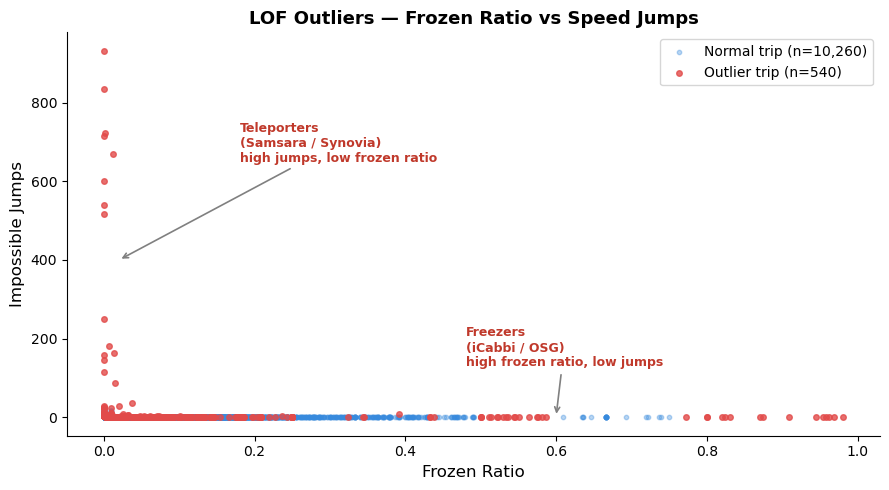

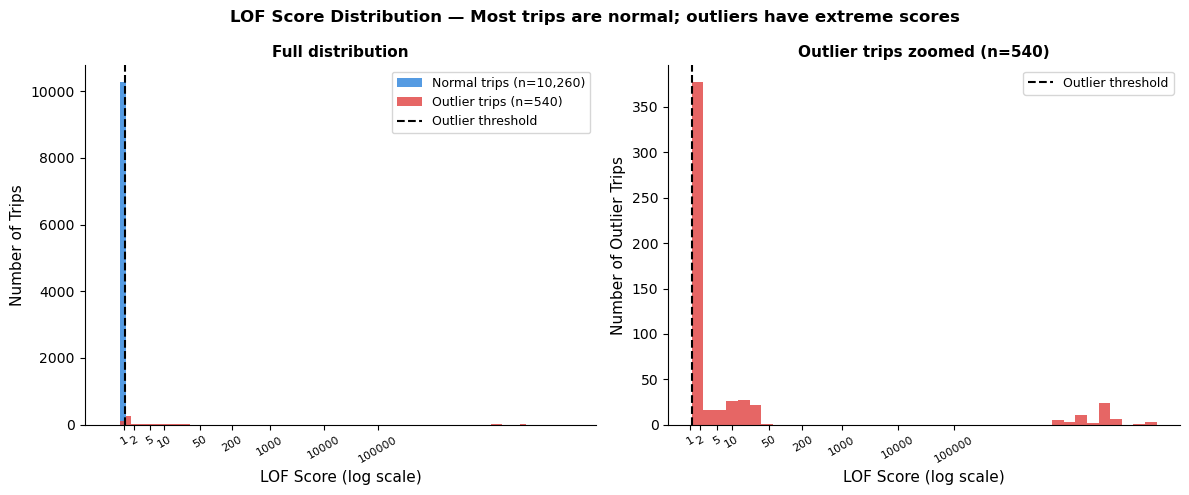


LOF columns merged into trip_features.
Total spatial outliers : 540
Total trips            : 14,859


In [8]:
# =============================================================================
# SECTION 6b — Spatial Consistency: LOF Outlier Detection
#
# Uses Local Outlier Factor (LOF) to identify trips with abnormal spatial
# consistency compared to their neighbors in feature space.
#
# Features:
#   - frozen_ratio     : proportion of pings frozen >120s and off-stop
#   - impossible_jumps : count of pings with implied speed >80 mph
#
# LOF compares each trip's local density to its 20 nearest neighbors.
# Trips in low-density regions relative to neighbors = high outlier score.
# =============================================================================

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Colors ────────────────────────────────────────────────────────────────────
OUTLIER_COLOR = '#E24B4A'
INLIER_COLOR  = '#378ADD'

# ── 1. Prepare features ───────────────────────────────────────────────────────
has_gps = trip_features[trip_features['gps_points'] > 0].copy()
has_gps['frozen_ratio']     = has_gps['frozen_ratio'].fillna(0)
has_gps['impossible_jumps'] = has_gps['impossible_jumps'].fillna(0)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(has_gps[['frozen_ratio', 'impossible_jumps']])

# ── 2. Fit LOF ────────────────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
has_gps['lof_label'] = lof.fit_predict(X_scaled)
has_gps['lof_score'] = -lof.negative_outlier_factor_

outliers = has_gps[has_gps['lof_label'] == -1]
inliers  = has_gps[has_gps['lof_label'] == 1]

# ── 3. Summary ────────────────────────────────────────────────────────────────
total_gps = len(has_gps)
print("=" * 55)
print("LOF SPATIAL CONSISTENCY RESULTS")
print("=" * 55)
print(f"Trips with GPS             : {total_gps:,}")
print(f"LOF outliers flagged       : {len(outliers):,} ({len(outliers)/total_gps:.1%})")
print(f"LOF inliers                : {len(inliers):,} ({len(inliers)/total_gps:.1%})")
print()
print(f"{'Metric':<25} {'Outliers':>12} {'Inliers':>12}")
print("-" * 50)
print(f"{'Avg frozen ratio':<25} {outliers['frozen_ratio'].mean():>12.3f} {inliers['frozen_ratio'].mean():>12.3f}")
print(f"{'Avg impossible jumps':<25} {outliers['impossible_jumps'].mean():>12.1f} {inliers['impossible_jumps'].mean():>12.1f}")
print(f"{'Avg GPS points':<25} {outliers['gps_points'].mean():>12.0f} {inliers['gps_points'].mean():>12.0f}")

# ── 4. Provider breakdown ─────────────────────────────────────────────────────
print("\n=== LOF Outliers by GPS Provider ===")
vendor_map = vendors[['vendor_id', 'vendor_label', 'gps_provider']].drop_duplicates()

outliers_v = outliers.merge(vendor_map, on='vendor_id', how='left')

provider_totals = (
    has_gps
    .merge(vendor_map, on='vendor_id', how='left')
    .groupby('gps_provider')['trip_id']
    .count()
    .reset_index()
    .rename(columns={'trip_id': 'provider_total'})
)

provider_outliers = (
    outliers_v
    .groupby('gps_provider')
    .agg(
        total_outliers = ('trip_id',         'count'),
        avg_frozen     = ('frozen_ratio',     'mean'),
        avg_jumps      = ('impossible_jumps', 'mean'),
        avg_lof_score  = ('lof_score',        'mean')
    )
    .reset_index()
    .sort_values('total_outliers', ascending=False)
    .merge(provider_totals, on='gps_provider')
)
provider_outliers['pct_of_provider'] = (
    provider_outliers['total_outliers'] /
    provider_outliers['provider_total'] * 100
).round(1)

print(provider_outliers[[
    'gps_provider', 'total_outliers', 'pct_of_provider',
    'avg_frozen', 'avg_jumps'
]].to_string(index=False))

# ── 5. Scatter plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    inliers['frozen_ratio'], inliers['impossible_jumps'],
    c=INLIER_COLOR, alpha=0.35, s=10,
    label=f'Normal trip (n={len(inliers):,})'
)
ax.scatter(
    outliers['frozen_ratio'], outliers['impossible_jumps'],
    c=OUTLIER_COLOR, alpha=0.8, s=16,
    label=f'Outlier trip (n={len(outliers):,})'
)
ax.annotate(
    'Teleporters\n(Samsara / Synovia)\nhigh jumps, low frozen ratio',
    xy=(0.02, 400), xytext=(0.18, 650),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=9, color='#C0392B', fontweight='bold'
)
ax.annotate(
    'Freezers\n(iCabbi / OSG)\nhigh frozen ratio, low jumps',
    xy=(0.6, 2), xytext=(0.48, 130),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=9, color='#C0392B', fontweight='bold'
)
ax.set_xlabel('Frozen Ratio', fontsize=12)
ax.set_ylabel('Impossible Jumps', fontsize=12)
ax.set_title('LOF Outliers — Frozen Ratio vs Speed Jumps', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── 6. LOF Score Distribution — log scale ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

inlier_scores  = np.log1p(inliers['lof_score'].values)
outlier_scores = np.log1p(outliers['lof_score'].values)
threshold_log  = np.log1p(outliers['lof_score'].min())
bins = np.linspace(0, max(inlier_scores.max(), outlier_scores.max()), 80)

tick_orig = [1, 2, 5, 10, 50, 200, 1000, 10000, 100000]
tick_log  = [np.log1p(v) for v in tick_orig]

# Left panel — full picture
ax1.hist(inlier_scores,  bins=bins, color=INLIER_COLOR,  alpha=0.85, label=f'Normal trips (n={len(inliers):,})')
ax1.hist(outlier_scores, bins=bins, color=OUTLIER_COLOR, alpha=0.85, label=f'Outlier trips (n={len(outliers):,})')
ax1.axvline(x=threshold_log, color='black', linestyle='--', linewidth=1.5, label='Outlier threshold')
ax1.set_xticks(tick_log)
ax1.set_xticklabels([str(v) for v in tick_orig], fontsize=8, rotation=30)
ax1.set_xlabel('LOF Score (log scale)', fontsize=11)
ax1.set_ylabel('Number of Trips', fontsize=11)
ax1.set_title('Full distribution', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right panel — zoomed into outliers only
ax2.hist(outlier_scores, bins=40, color=OUTLIER_COLOR, alpha=0.85)
ax2.axvline(x=threshold_log, color='black', linestyle='--', linewidth=1.5, label='Outlier threshold')
ax2.set_xticks(tick_log)
ax2.set_xticklabels([str(v) for v in tick_orig], fontsize=8, rotation=30)
ax2.set_xlabel('LOF Score (log scale)', fontsize=11)
ax2.set_ylabel('Number of Outlier Trips', fontsize=11)
ax2.set_title(f'Outlier trips zoomed (n={len(outliers):,})', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('LOF Score Distribution — Most trips are normal; outliers have extreme scores',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7. Merge LOF results back to trip_features ────────────────────────────────
trip_features = trip_features.merge(
    has_gps[['trip_id', 'lof_label', 'lof_score']],
    on='trip_id', how='left'
)
trip_features['lof_label'] = trip_features['lof_label'].fillna(1)
trip_features['lof_score'] = trip_features['lof_score'].fillna(0)

print(f"\nLOF columns merged into trip_features.")
print(f"Total spatial outliers : {(trip_features['lof_label']==-1).sum():,}")
print(f"Total trips            : {len(trip_features):,}")

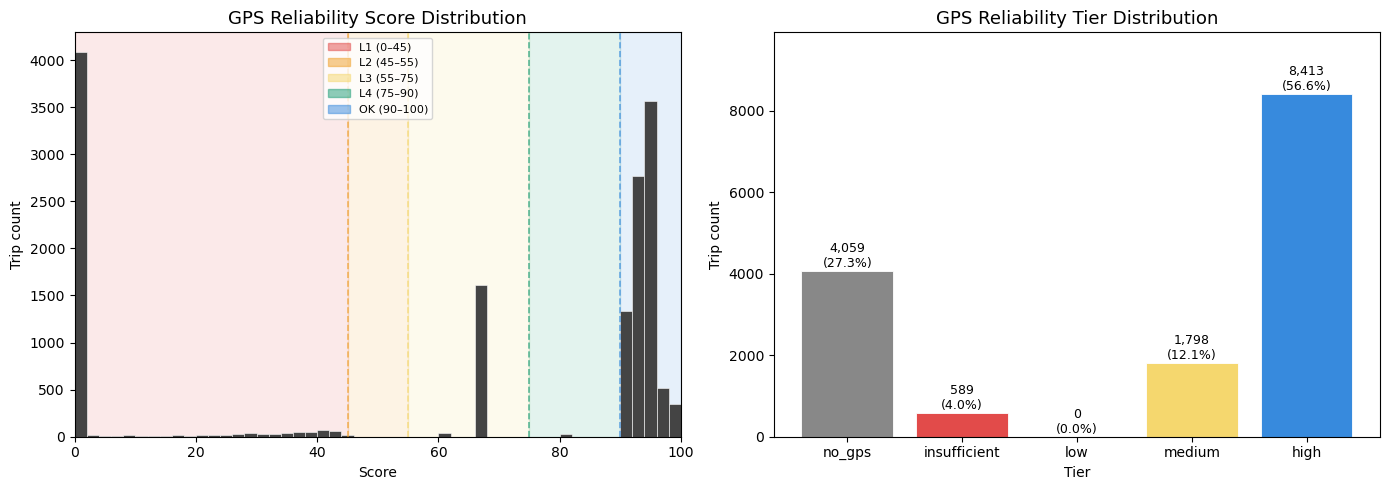

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores = trip_features["gps_reliability_score"]
tiers  = trip_features["gps_reliability_tier"]

# ── Left: histogram of scores with band shading ───────────────────
band_colors = {
    "L1 (0–45)":   ("#E24B4A", 0,  45),
    "L2 (45–55)":  ("#EF9F27", 45, 55),
    "L3 (55–75)":  ("#F5D76E", 55, 75),
    "L4 (75–90)":  ("#1D9E75", 75, 90),
    "OK (90–100)": ("#378ADD", 90, 100),
}

ax = axes[0]
for label, (color, lo, hi) in band_colors.items():
    ax.axvspan(lo, hi, alpha=0.12, color=color)

ax.hist(scores, bins=50, color="#444444", edgecolor="white", linewidth=0.4)

for label, (color, lo, hi) in band_colors.items():
    ax.axvline(lo, color=color, linewidth=1.2, linestyle="--", alpha=0.7)

ax.set_title("GPS Reliability Score Distribution", fontsize=13)
ax.set_xlabel("Score")
ax.set_ylabel("Trip count")
ax.set_xlim(0, 100)

patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
           for l, (c, lo, hi) in band_colors.items()]
ax.legend(handles=patches, fontsize=8, loc="upper center")

# ── Right: tier bar chart ─────────────────────────────────────────
tier_order  = ["no_gps", "insufficient", "low", "medium", "high"]
tier_colors = ["#888888", "#E24B4A", "#EF9F27", "#F5D76E", "#378ADD"]
tier_counts = tiers.value_counts().reindex(tier_order, fill_value=0)

ax2 = axes[1]
bars = ax2.bar(tier_order, tier_counts.values, color=tier_colors, edgecolor="white", linewidth=0.6)

for bar, count in zip(bars, tier_counts.values):
    pct = count / len(tiers) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

ax2.set_title("GPS Reliability Tier Distribution", fontsize=13)
ax2.set_xlabel("Tier")
ax2.set_ylabel("Trip count")
ax2.set_ylim(0, tier_counts.max() * 1.18)

plt.tight_layout()
plt.show()

## 9 — Export Outputs

In [10]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Trip-level output ─────────────────────────────────────────────────────
trip_cols = [
    "trip_id", "date", "vendor_id", "route_id", "trip_type",
    "vehicle_id", "vehicle_type", "tracking_device_id", "school_id", "source",
    "gps_points", "coverage_rate", "max_gap_s", "large_gap_count",
    "frozen_ratio", "impossible_jumps",
    "gps_reliability_score", "gps_reliability_tier",
    "triggered_layer", "trigger_reason",
    "ct_flag_low_coverage", "ct_flag_high_gap", "ct_flag_many_gaps",
    "peer_source", "route_peer_n",
    "planned_stops", "completed_stops", "stop_completion_rate",
    "ontime_rate", "sequence_score",
    "execution_score", "execution_status",
    "flag_zero_ping", "is_anomalous", "flag_low_completion",
]
trip_out = trip_features[[c for c in trip_cols if c in trip_features.columns]]
trip_out.to_csv(OUTPUT_DIR + "trip_scores.csv", index=False)
print(f"Saved trip_scores.csv        — {len(trip_out):,} rows")

Saved trip_scores.csv        — 14,859 rows


## 10 — Summary

In [11]:
print("=" * 60)
print("GPS RELIABILITY & EXECUTION PERFORMANCE — SUMMARY")
print("=" * 60)
print(f"\nTotal trips : {len(trip_features):,}")
print(f"Date range  : {trip_features['date'].min()} → {trip_features['date'].max()}")

print("\n--- GPS Reliability Tiers ---")
for tier in ["no_gps", "insufficient", "low", "medium", "high"]:
    n   = (trip_features["gps_reliability_tier"] == tier).sum()
    pct = n / len(trip_features)
    bar = "█" * int(pct * 30)
    print(f"  {tier:<15}: {n:5,} ({pct:5.1%})  {bar}")

print("\n--- Decision Tree — Layer Trigger Rates ---")
n_no_gps = (trip_features["gps_reliability_tier"] == "no_gps").sum()
pct_no_gps = n_no_gps / len(trip_features)
print(f"  No GPS (L1): {n_no_gps:5,} ({pct_no_gps:.1%})")

n_l1 = (trip_features["trigger_reason"].str.startswith("low_coverage", na=False)).sum()
pct_l1 = n_l1 / len(trip_features)
print(f"  Layer 1    : {n_l1:5,} ({pct_l1:.1%})  (low coverage)")

for layer in [2, 3, 4]:
    n   = (trip_features["triggered_layer"] == layer).sum()
    pct = n / len(trip_features)
    print(f"  Layer {layer}    : {n:5,} ({pct:.1%})")

n_all = trip_features["triggered_layer"].isna().sum()
print(f"  All passed : {n_all:5,} ({n_all/len(trip_features):.1%})")

GPS RELIABILITY & EXECUTION PERFORMANCE — SUMMARY

Total trips : 14,859
Date range  : 2025-09-01 00:00:00+00:00 → 2026-02-13 00:00:00+00:00

--- GPS Reliability Tiers ---
  no_gps         : 4,059 (27.3%)  ████████
  insufficient   :   589 ( 4.0%)  █
  low            :     0 ( 0.0%)  
  medium         : 1,798 (12.1%)  ███
  high           : 8,413 (56.6%)  ████████████████

--- Decision Tree — Layer Trigger Rates ---
  No GPS (L1): 4,059 (27.3%)
  Layer 1    :   589 (4.0%)  (low coverage)
  Layer 2    :     0 (0.0%)
  Layer 3    : 1,654 (11.1%)
  Layer 4    :   144 (1.0%)
  All passed : 8,413 (56.6%)


DBSCAN results (GPS trips only):
  eps=0.5, min_samples=108
  Clusters found     : 1
  Anomalous trips    : 1,581 (14.6%)
  Normal trips       : 9,219 (85.4%)

Decision Tree vs DBSCAN overlap (GPS trips only):
  Both flag as anomaly      : 127
  DBSCAN only               : 1,454  ← trips DT missed
  Decision Tree only        : 462  ← trips DBSCAN missed
  Both say normal           : 8,757


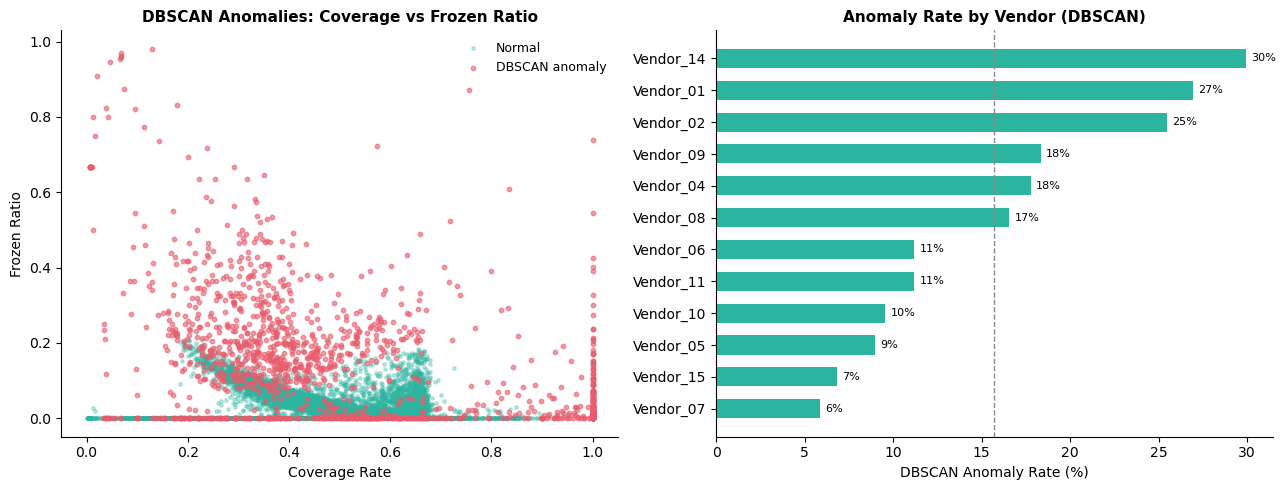

Saved: dbscan_anomaly.png

Feature profile — DBSCAN anomaly vs normal (GPS trips only):
                coverage_rate  frozen_ratio  gap_rate  has_impossible_jump
dbscan_anomaly                                                            
Normal                  0.483         0.027     0.057                0.000
Anomaly                 0.552         0.138     0.054                0.238


In [12]:
# =============================================================================
# SECTION 8 — DBSCAN Anomaly Detection on GPS Quality Features
#
# Purpose:
#   Complement the decision tree (rule-based) with a data-driven approach.
#   DBSCAN finds dense clusters of "normal" trips and labels outliers as -1.
#   These outliers are trips whose GPS quality profile is unusual relative
#   to the rest of the data — without needing manually-set thresholds.
#
# Features used (all GPS quality dimensions):
#   coverage_rate, frozen_ratio, large_gap_count (normalised by duration),
#   impossible_jumps (binary presence)
#
# Output:
#   dbscan_label    : cluster id (-1 = anomaly)
#   dbscan_anomaly  : 1 if label == -1, else 0
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Feature preparation ───────────────────────────────────────────────────
# Only run DBSCAN on trips that have GPS data (zero-ping trips are already
# flagged by the decision tree and would dominate as a degenerate cluster)
dbscan_input = trip_features[trip_features["gps_points"] > 0].copy()

# Normalise large_gap_count by trip duration to make it comparable across
# trips of different lengths
dbscan_input["gap_rate"] = (
    dbscan_input["large_gap_count"] /
    (dbscan_input["trip_duration_s"] / 60).replace(0, np.nan)
).fillna(0)

# Binary impossible-jump flag (presence matters more than count)
dbscan_input["has_impossible_jump"] = (dbscan_input["impossible_jumps"] > 0).astype(int)

features = [
    "coverage_rate",
    "frozen_ratio",
    "gap_rate",
    "has_impossible_jump",
]

# Fill NaN (e.g. frozen_ratio is NaN for trips with 0 pings — already excluded)
feature_df = dbscan_input[features].fillna(0)

# Standardise: DBSCAN is distance-based, so scale matters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

# ── Tune and run DBSCAN ───────────────────────────────────────────────────
# eps    : neighbourhood radius in scaled space. Start at 0.5; lower → stricter.
# min_samples: min points to form a dense region. ~1% of dataset is a reasonable start.
EPS         = 0.5
MIN_SAMPLES = max(5, int(len(X_scaled) * 0.01))

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_input["dbscan_label"]   = db.fit_predict(X_scaled)
dbscan_input["dbscan_anomaly"] = (dbscan_input["dbscan_label"] == -1).astype(int)

# Merge back onto trip_features
trip_features = trip_features.merge(
    dbscan_input[["trip_id", "dbscan_label", "dbscan_anomaly"]],
    on="trip_id", how="left"
)
# Zero-ping trips: not run through DBSCAN, label as a separate category
trip_features["dbscan_label"]   = trip_features["dbscan_label"].fillna(-2).astype(int)
trip_features["dbscan_anomaly"] = trip_features["dbscan_anomaly"].fillna(1).astype(int)
# -2 = zero-ping (not sent to DBSCAN); -1 = DBSCAN outlier; ≥0 = cluster member

n_anomaly  = (dbscan_input["dbscan_anomaly"] == 1).sum()
n_total_gps = len(dbscan_input)
n_clusters = dbscan_input[dbscan_input["dbscan_label"] >= 0]["dbscan_label"].nunique()

print("DBSCAN results (GPS trips only):")
print(f"  eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"  Clusters found     : {n_clusters}")
print(f"  Anomalous trips    : {n_anomaly:,} ({n_anomaly/n_total_gps:.1%})")
print(f"  Normal trips       : {n_total_gps - n_anomaly:,} ({(n_total_gps-n_anomaly)/n_total_gps:.1%})")

# ── Compare DBSCAN vs decision tree ───────────────────────────────────────
# How much do the two methods agree?
gps_trips = trip_features[trip_features["gps_points"] > 0].copy()
gps_trips["dt_anomaly"] = gps_trips["gps_reliability_tier"].isin(
    ["no_gps", "insufficient"]
).astype(int)

both    = ((gps_trips["dbscan_anomaly"] == 1) & (gps_trips["dt_anomaly"] == 1)).sum()
db_only = ((gps_trips["dbscan_anomaly"] == 1) & (gps_trips["dt_anomaly"] == 0)).sum()
dt_only = ((gps_trips["dbscan_anomaly"] == 0) & (gps_trips["dt_anomaly"] == 1)).sum()
neither = ((gps_trips["dbscan_anomaly"] == 0) & (gps_trips["dt_anomaly"] == 0)).sum()

print("\nDecision Tree vs DBSCAN overlap (GPS trips only):")
print(f"  Both flag as anomaly      : {both:,}")
print(f"  DBSCAN only               : {db_only:,}  ← trips DT missed")
print(f"  Decision Tree only        : {dt_only:,}  ← trips DBSCAN missed")
print(f"  Both say normal           : {neither:,}")

# ── Visualisation: DBSCAN clusters in coverage_rate vs frozen_ratio space ─
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: coverage_rate vs frozen_ratio, colored by DBSCAN label
ax = axes[0]
normal  = dbscan_input[dbscan_input["dbscan_anomaly"] == 0]
anomaly = dbscan_input[dbscan_input["dbscan_anomaly"] == 1]

ax.scatter(normal["coverage_rate"],  normal["frozen_ratio"].fillna(0),
           s=6, alpha=0.3, color="#2BB5A0", label="Normal")
ax.scatter(anomaly["coverage_rate"], anomaly["frozen_ratio"].fillna(0),
           s=10, alpha=0.6, color="#E85C6C", label="DBSCAN anomaly", zorder=3)

ax.set_xlabel("Coverage Rate", fontsize=10)
ax.set_ylabel("Frozen Ratio", fontsize=10)
ax.set_title("DBSCAN Anomalies: Coverage vs Frozen Ratio", fontsize=11, fontweight="bold")
ax.legend(fontsize=9, frameon=False)
ax.spines[["top","right"]].set_visible(False)

# Right: bar chart — anomaly rate by vendor
vendor_dbscan = (
    trip_features[trip_features["gps_points"] > 0]
    .merge(
        trip_features[["trip_id","vendor_id"]].drop_duplicates()
        if "vendor_id" in trip_features.columns
        else pd.DataFrame(columns=["trip_id","vendor_id"]),
        on="trip_id", how="left", suffixes=("","_v")
    )
)
vendor_map_local = vendors[["vendor_id","vendor_label"]].drop_duplicates()
_drop = [c for c in ["vendor_label"] if c in trip_features.columns]
vendor_dbscan2 = (
    trip_features[trip_features["gps_points"] > 0]
    .drop(columns=_drop, errors="ignore")
    .merge(vendor_map_local, on="vendor_id", how="left")
    .groupby("vendor_label")
    .agg(
        total     = ("trip_id",        "nunique"),
        anomalies = ("dbscan_anomaly", "sum"),
    )
    .assign(anomaly_rate=lambda d: d["anomalies"] / d["total"])
    .query("total >= 30")
    .sort_values("anomaly_rate", ascending=True)
    .reset_index()
)

ax2 = axes[1]
colors2 = ["#E85C6C" if r > 0.3 else "#2BB5A0" for r in vendor_dbscan2["anomaly_rate"]]
bars = ax2.barh(vendor_dbscan2["vendor_label"], vendor_dbscan2["anomaly_rate"] * 100,
                color=colors2, height=0.6)
ax2.axvline(vendor_dbscan2["anomaly_rate"].mean() * 100,
            color="#888888", linewidth=1, linestyle="--")
ax2.set_xlabel("DBSCAN Anomaly Rate (%)", fontsize=10)
ax2.set_title("Anomaly Rate by Vendor (DBSCAN)", fontsize=11, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
for bar, val in zip(bars, vendor_dbscan2["anomaly_rate"]):
    ax2.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.0%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("dbscan_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dbscan_anomaly.png")

# ── Feature profile of anomalous vs normal trips ───────────────────────────
print("\nFeature profile — DBSCAN anomaly vs normal (GPS trips only):")
profile = (
    dbscan_input
    .groupby("dbscan_anomaly")[features]
    .mean()
    .round(3)
    .rename(index={0: "Normal", 1: "Anomaly"})
)
print(profile.to_string())

## 6c — Geographical Analysis: Spatial Consistency

Combined heatmap of GPS freeze locations (red) and impossible speed jump locations (green).
Shows whether spatial failures cluster geographically (environmental) or are random (device issue).
Red = frozen pings · Green = speed jump pings · Darker = higher concentration

In [13]:
!pip install folium

In [14]:
print(vendors.columns.tolist())

['vendor_id', 'vendor_label', 'gps_provider', 'polling_interval_s']


In [15]:
print("pings columns:", pings.columns.tolist())
print("pings vendor_id sample:", pings['vendor_id'].value_counts().head() if 'vendor_id' in pings.columns else "NO vendor_id IN PINGS")
print()
print("vendors sample:")
print(vendors.head())
print()
print("polling_lookup:")
print(polling_lookup)

NameError: name 'pings' is not defined

In [ ]:
# The pings dataframe already has the flags and polling interval
# Just rename the existing columns to match what we need

print("Existing relevant columns:", [c for c in pings.columns if 'frozen' in c or 'jump' in c or 'polling' in c])

# Fix polling interval — use _x or _y whichever has data
if 'polling_interval_s_x' in pings.columns:
    pings['polling_interval_s'] = pings['polling_interval_s_x'].fillna(
        pings['polling_interval_s_y']).fillna(30)

# Rename existing flag columns to match our naming
if 'point_frozen' in pings.columns:
    pings['ping_frozen'] = pings['point_frozen'].astype(int)

if 'point_impossible_jump' in pings.columns:
    pings['ping_impossible_speed'] = pings['point_impossible_jump'].astype(int)

if 'gap_is_large' in pings.columns:
    pings['ping_gap_adjacent'] = pings['gap_is_large'].astype(int)

# Anomaly type
def get_anomaly_type(row):
    types = []
    if row.get('ping_gap_adjacent', 0):     types.append('gap_adjacent')
    if row.get('ping_impossible_speed', 0): types.append('impossible_speed')
    if row.get('ping_frozen', 0):           types.append('frozen')
    return ','.join(types) if types else 'clean'

pings['ping_anomaly_type'] = pings.apply(get_anomaly_type, axis=1)
pings['ping_is_anomalous']  = (pings['ping_anomaly_type'] != 'clean').astype(int)

# Save
ping_classifications = pings[[
    'trip_id', 'lat', 'lng', 'timestamp',
    'gap_s', 'dist_m', 'speed_mps',
    'ping_frozen', 'ping_impossible_speed', 'ping_gap_adjacent',
    'ping_anomaly_type', 'ping_is_anomalous'
]].copy()

import os

# Create outputs directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

ping_classifications.to_csv(OUTPUT_DIR + 'ping_classifications.csv', index=False)

print(f"Total pings        : {len(ping_classifications):,}")
print(f"Frozen pings       : {ping_classifications['ping_frozen'].sum():,} ({ping_classifications['ping_frozen'].mean():.1%})")
print(f"Speed jump pings   : {ping_classifications['ping_impossible_speed'].sum():,} ({ping_classifications['ping_impossible_speed'].mean():.1%})")
print(f"Saved to           : {OUTPUT_DIR}ping_classifications.csv")

print(f"Total pings        : {len(ping_classifications):,}")
print(f"Frozen pings       : {ping_classifications['ping_frozen'].sum():,} ({ping_classifications['ping_frozen'].mean():.1%})")
print(f"Speed jump pings   : {ping_classifications['ping_impossible_speed'].sum():,} ({ping_classifications['ping_impossible_speed'].mean():.1%})")
print(f"Saved to           : {OUTPUT_DIR}ping_classifications.csv")

In [ ]:
import os
import gc

print("Generating ping classifications...")

# pings already has point_frozen, point_impossible_jump, gap_is_large
print("Relevant columns found:", [c for c in pings.columns if 'frozen' in c or 'jump' in c or 'gap_is_large' in c])

# Rename existing columns
pings['ping_frozen']          = pings['point_frozen'].astype(int)
pings['ping_impossible_speed'] = pings['point_impossible_jump'].astype(int)
pings['ping_gap_adjacent']    = pings['gap_is_large'].astype(int)

# Anomaly type
def get_anomaly_type(row):
    types = []
    if row['ping_gap_adjacent']:      types.append('gap_adjacent')
    if row['ping_impossible_speed']:  types.append('impossible_speed')
    if row['ping_frozen']:            types.append('frozen')
    return ','.join(types) if types else 'clean'

pings['ping_anomaly_type'] = pings.apply(get_anomaly_type, axis=1)
pings['ping_is_anomalous']  = (pings['ping_anomaly_type'] != 'clean').astype(int)

# Select output columns
ping_classifications = pings[[
    'trip_id', 'lat', 'lng', 'timestamp',
    'gap_s', 'dist_m', 'speed_mps',
    'ping_frozen', 'ping_impossible_speed', 'ping_gap_adjacent',
    'ping_anomaly_type', 'ping_is_anomalous'
]].copy()

# Save
os.makedirs(OUTPUT_DIR, exist_ok=True)
ping_classifications.to_csv(OUTPUT_DIR + 'ping_classifications.csv', index=False)

print(f"Total pings        : {len(ping_classifications):,}")
print(f"Frozen pings       : {ping_classifications['ping_frozen'].sum():,} ({ping_classifications['ping_frozen'].mean():.1%})")
print(f"Speed jump pings   : {ping_classifications['ping_impossible_speed'].sum():,} ({ping_classifications['ping_impossible_speed'].mean():.1%})")
print(f"Saved to           : {OUTPUT_DIR}ping_classifications.csv")

In [ ]:
import pandas as pd
import numpy as np
import folium
import gc

MAP_CENTER = [44.98, -93.20]
ZOOM = 12

# ── Load only genuine frozen pings (from trips with frozen_ratio > 10%) ───────
ping_classifications = pd.read_csv(OUTPUT_DIR + 'ping_classifications.csv',
                    usecols=['trip_id', 'lat', 'lng', 'ping_frozen', 'ping_impossible_speed'],
                    dtype={'lat': 'float32', 'lng': 'float32',
                           'ping_frozen': 'int8', 'ping_impossible_speed': 'int8'})

ping_classifications = ping_classifications[
    (ping_classifications['lat'] > 44) & 
    (ping_classifications['lng'] < -92)
]

# Filter frozen pings to only bad freeze trips (frozen_ratio > 10%)
frozen = ping_classifications[
    (ping_classifications['ping_frozen'] == 1) &
    (ping_classifications['trip_id'].isin(bad_frozen_trips))
][['lat', 'lng']].copy()

# Speed jumps — all of them (only 7,780 total, all genuine)
speed = ping_classifications[
    ping_classifications['ping_impossible_speed'] == 1
][['lat', 'lng']].copy()

del ping_classifications; gc.collect()

print(f"Genuine frozen pings : {len(frozen):,}")
print(f"Speed jump pings     : {len(speed):,}")

# Sample
frozen_sample = frozen.sample(min(8000, len(frozen)), random_state=42)
speed_sample  = speed.sample(min(5000, len(speed)), random_state=42)
del frozen, speed; gc.collect()

# ── MAP 1 — Frozen GPS Route Corridors ───────────────────────────────────────
map_frozen = folium.Map(location=MAP_CENTER, zoom_start=ZOOM,
                        tiles='CartoDB positron')

for _, row in frozen_sample.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=2,
        color='#de2d26',
        fill=True,
        fill_color='#de2d26',
        fill_opacity=0.5,
        weight=0
    ).add_to(map_frozen)

map_frozen.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed; top:15px; left:50%; transform:translateX(-50%);
            z-index:1000; background:white; padding:8px 16px;
            border-radius:6px; border:2px solid #de2d26;
            font-size:14px; font-weight:bold; white-space:nowrap;">
    🔴 Frozen GPS — Genuine Failures Only (frozen ratio &gt; 10%)
</div>
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px 14px; border-radius:6px;
            border:2px solid #ccc; font-size:12px; line-height:1.8;">
    <b>1,427 trips</b> with frozen ratio &gt; 10%<br>
    Each red dot = one frozen GPS ping location<br>
    <b>→ Do freezes cluster on specific routes/areas?</b>
</div>
"""))
map_frozen.save(OUTPUT_DIR + 'map1_frozen_corridors.html')
print("Map 1 saved")
del frozen_sample; gc.collect()

# ── MAP 2 — Speed Jump Route Corridors ───────────────────────────────────────
map_speed = folium.Map(location=MAP_CENTER, zoom_start=ZOOM,
                       tiles='CartoDB positron')

for _, row in speed_sample.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=2,
        color='#2171b5',
        fill=True,
        fill_color='#2171b5',
        fill_opacity=0.5,
        weight=0
    ).add_to(map_speed)

map_speed.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed; top:15px; left:50%; transform:translateX(-50%);
            z-index:1000; background:white; padding:8px 16px;
            border-radius:6px; border:2px solid #2171b5;
            font-size:14px; font-weight:bold; white-space:nowrap;">
    🔵 Speed Jumps — All GPS Teleportations
</div>
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px 14px; border-radius:6px;
            border:2px solid #ccc; font-size:12px; line-height:1.8;">
    <b>7,780 speed jump pings</b> plotted<br>
    Each blue dot = one GPS teleportation<br>
    <b>→ Do jumps follow specific route paths?</b>
</div>
"""))
map_speed.save(OUTPUT_DIR + 'map2_speed_corridors.html')
print("Map 2 saved")
del speed_sample; gc.collect()

# Display map 1
map_frozen


In [ ]:
map_speed

In [ ]:
import folium
import pandas as pd

MAP_CENTER = [44.98, -93.20]
ZOOM = 12

# Update this path to match your local file location
trip_stop = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Exploratory /Live case/Cleaned Data/trip_stop_w_status.csv',
    usecols=['stop_lat', 'stop_lng', 'gps_health_flag'])

trip_stop = trip_stop.dropna(subset=['stop_lat', 'stop_lng'])
print(f"Stop visits: {len(trip_stop):,}")

health_colors = {
    'healthy':      '#2196F3',
    'intermittent': '#FF9800',
    'severe_gap':   '#E53935',
    'very_sparse':  '#9C27B0'
}

map3 = folium.Map(location=MAP_CENTER, zoom_start=ZOOM, tiles='CartoDB positron')

for flag, color in health_colors.items():
    subset = trip_stop[trip_stop['gps_health_flag'] == flag]
    sample = subset.sample(min(3000, len(subset)), random_state=42)
    for _, row in sample.iterrows():
        folium.CircleMarker(
            location=[row['stop_lat'], row['stop_lng']],
            radius=3,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            weight=0
        ).add_to(map3)

folium.LayerControl().add_to(map3)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:12px 16px; border-radius:6px;
            border:2px solid #ccc; font-size:13px; line-height:1.8;">
    <b>GPS Health at Stop Level</b><br>
    <span style="color:#2196F3">&#11044;</span> Healthy (23%)<br>
    <span style="color:#FF9800">&#11044;</span> Intermittent (10%)<br>
    <span style="color:#E53935">&#11044;</span> Severe Gap (67%)<br>
    <span style="color:#9C27B0">&#11044;</span> Very Sparse (0.2%)
</div>
"""
map3.get_root().html.add_child(folium.Element(legend_html))

title_html = """
<div style="position:fixed; top:15px; left:50%; transform:translateX(-50%);
            z-index:1000; background:white; padding:8px 16px;
            border-radius:6px; border:2px solid #ccc;
            font-size:14px; font-weight:bold; white-space:nowrap;">
    GPS Coverage by Stop Location
</div>
"""
map3.get_root().html.add_child(folium.Element(title_html))

map3.save(OUTPUT_DIR + 'map3_gps_coverage.html')
print("Map saved")
map3

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import gc

# =============================================================================
# SPATIAL CORRELATION ANALYSIS
# Grid-based approach — divide Minneapolis into 500m x 500m cells
# Compare frozen pings, speed jumps, and severe gap stops per cell
# =============================================================================

# ── Grid parameters ───────────────────────────────────────────────────────────
# 1 degree lat ≈ 111km, 1 degree lng ≈ 85km in Minneapolis
# 500m ≈ 0.0045 degrees lat, 0.0059 degrees lng
GRID_LAT = 0.0045
GRID_LNG = 0.0059

def assign_grid(lat, lng):
    """Assign a grid cell ID to each coordinate."""
    grid_lat = np.floor(lat / GRID_LAT).astype(int)
    grid_lng = np.floor(lng / GRID_LNG).astype(int)
    return grid_lat.astype(str) + '_' + grid_lng.astype(str)

# ── Load frozen pings ─────────────────────────────────────────────────────────
print("Loading frozen pings...")
ping_df = pd.read_csv(OUTPUT_DIR + 'ping_classifications.csv',
                      usecols=['trip_id', 'lat', 'lng', 'ping_frozen', 'ping_impossible_speed'],
                      dtype={'lat': 'float32', 'lng': 'float32',
                             'ping_frozen': 'int8', 'ping_impossible_speed': 'int8'})

ping_df = ping_df[(ping_df['lat'] > 44) & (ping_df['lng'] < -92)]

# Filter frozen to genuine failures only
ping_df = ping_df.merge(
    pd.DataFrame({'trip_id': bad_frozen_trips}),
    on='trip_id', how='inner'
)

frozen = ping_df[ping_df['ping_frozen'] == 1][['lat', 'lng']].copy()
speed  = ping_df[ping_df['ping_impossible_speed'] == 1][['lat', 'lng']].copy()
del ping_df; gc.collect()

print(f"Frozen pings : {len(frozen):,}")
print(f"Speed jumps  : {len(speed):,}")

# ── Load stop GPS health ──────────────────────────────────────────────────────
print("Loading stop data...")
stops = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Exploratory /Live case/Cleaned Data/trip_stop_w_status.csv',
                    usecols=['stop_lat', 'stop_lng', 'gps_health_flag'])
stops = stops.dropna(subset=['stop_lat', 'stop_lng'])
severe = stops[stops['gps_health_flag'] == 'severe_gap'][['stop_lat', 'stop_lng']].copy()
del stops; gc.collect()
print(f"Severe gap stops : {len(severe):,}")

# ── Assign grid cells ─────────────────────────────────────────────────────────
frozen['grid'] = assign_grid(frozen['lat'].values, frozen['lng'].values)
speed['grid']  = assign_grid(speed['lat'].values,  speed['lng'].values)
severe['grid'] = assign_grid(severe['stop_lat'].values, severe['stop_lng'].values)

# ── Count per grid cell ───────────────────────────────────────────────────────
frozen_counts = frozen.groupby('grid').size().reset_index(name='frozen_count')
speed_counts  = speed.groupby('grid').size().reset_index(name='speed_count')
severe_counts = severe.groupby('grid').size().reset_index(name='severe_count')

# ── Merge all grid counts ─────────────────────────────────────────────────────
grid = frozen_counts.merge(speed_counts,  on='grid', how='outer')
grid = grid.merge(severe_counts, on='grid', how='outer')
grid = grid.fillna(0)

print(f"\nTotal grid cells with any data : {len(grid):,}")
print(f"Grid cells with frozen pings   : {(grid['frozen_count'] > 0).sum():,}")
print(f"Grid cells with speed jumps    : {(grid['speed_count'] > 0).sum():,}")
print(f"Grid cells with severe stops   : {(grid['severe_count'] > 0).sum():,}")

# ── Pearson Correlation ───────────────────────────────────────────────────────
print("\n=== SPATIAL CORRELATION RESULTS ===")

# Frozen vs Severe Gap
r1, p1 = stats.pearsonr(grid['frozen_count'], grid['severe_count'])
print(f"Frozen pings vs Severe gap stops : r = {r1:.3f}, p = {p1:.4f}")

# Speed vs Severe Gap
r2, p2 = stats.pearsonr(grid['speed_count'], grid['severe_count'])
print(f"Speed jumps vs Severe gap stops  : r = {r2:.3f}, p = {p2:.4f}")

# Frozen vs Speed
r3, p3 = stats.pearsonr(grid['frozen_count'], grid['speed_count'])
print(f"Frozen pings vs Speed jumps      : r = {r3:.3f}, p = {p3:.4f}")

# Significance check
def interpret(r, p):
    sig = "statistically significant (p<0.05)" if p < 0.05 else "not significant"
    strength = "strong" if abs(r) > 0.6 else "moderate" if abs(r) > 0.3 else "weak"
    return f"{strength} correlation, {sig}"

print(f"\nInterpretation:")
print(f"Frozen vs Severe : {interpret(r1, p1)}")
print(f"Speed vs Severe  : {interpret(r2, p2)}")
print(f"Frozen vs Speed  : {interpret(r3, p3)}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('frozen_count', 'severe_count', r1, p1,
     'Frozen Pings per Cell', 'Severe Gap Stops per Cell',
     'Frozen GPS vs Severe Gap Stops', '#E24B4A'),
    ('speed_count',  'severe_count', r2, p2,
     'Speed Jumps per Cell',  'Severe Gap Stops per Cell',
     'Speed Jumps vs Severe Gap Stops', '#2171b5'),
    ('frozen_count', 'speed_count',  r3, p3,
     'Frozen Pings per Cell', 'Speed Jumps per Cell',
     'Frozen GPS vs Speed Jumps', '#9C27B0'),
]

for ax, (x_col, y_col, r, p, xlabel, ylabel, title, color) in zip(axes, pairs):
    # Only plot cells where both > 0 for clarity
    subset = grid[(grid[x_col] > 0) & (grid[y_col] > 0)]
    ax.scatter(subset[x_col], subset[y_col],
               alpha=0.5, s=20, color=color)

    # Regression line
    if len(subset) > 2:
        m, b = np.polyfit(subset[x_col], subset[y_col], 1)
        x_line = np.linspace(subset[x_col].min(), subset[x_col].max(), 100)
        ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{title}\nr = {r:.3f}, p = {p:.4f}', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Spatial Correlation: GPS Failures Across Failure Types',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7 — Execution Performance Score

Three components, all from `route_stops_info`:

| Component | Weight | Notes |
|-----------|--------|-------|
| Stop completion | 40% | completed ÷ planned stops |
| On-time rate | 40% | share with \|completed_diff\| ≤ 10 min |
| Stop sequence | 20% | Spearman rank corr, better of asc/desc direction |

`execution_status` values:
- `scored` — all components available
- `partial` — scored but ≥1 component missing (see `execution_note`)
- `no_gps` — zero pings, GPS absent
- `insufficient_gps` — GPS reliability too low
- `no_students` — operational event, not execution failure
- `no_stop_data` — route_stops_info empty

In [ ]:
route_stops = pd.read_csv(DATA_DIR + "route_stops.csv")

route_stops["planned_order"] = route_stops.groupby(
    ["route_id", "trip_type"]
).cumcount()

stop_order_map = route_stops.set_index("route_stop_id")["planned_order"].to_dict()

print(f"stop_order_map built: {len(stop_order_map):,} entries")


ONTIME_THRESHOLD_MIN = 10
W_COMPLETION         = 0.40
W_ONTIME             = 0.40
W_SEQUENCE           = 0.20

In [ ]:
def compute_stop_sequence_score(completed_times):
    """
    Measures stop sequence adherence using Spearman rank correlation
    between observed completion order and planned order from route_stops.csv.

    Takes the better of ascending/descending direction to handle both
    to_school (planned order ascending) and from_school (geofence triggers
    in descending planned_order) trip types.

    Returns value in [0, 1]. Returns NaN if fewer than 2 stops completed
    or planned order cannot be determined.
    """
    if not completed_times or len(completed_times) < 2:
        return np.nan

    try:
        sorted_by_time = sorted(completed_times, key=lambda x: x[1])
    except Exception:
        return np.nan

    # Get planned_order for each completed stop
    planned_positions = [
        stop_order_map.get(int(k), np.nan)
        for k, _ in sorted_by_time
    ]

    known = [p for p in planned_positions if not pd.isna(p)]
    if len(known) < 2:
        return np.nan

    # Count consecutive pairs in ascending and descending order
    ascending  = sum(1 for i in range(len(known)-1) if known[i] < known[i+1])
    descending = sum(1 for i in range(len(known)-1) if known[i] > known[i+1])
    total_pairs = len(known) - 1

    # Take the more consistent direction (handles both trip_type directions)
    return max(ascending, descending) / total_pairs


def compute_execution_score(row):
    """
    Returns (execution_score, exec_completion_rate, ontime_rate,
             sequence_score, execution_status, execution_note).
    """
    null_result = (np.nan, np.nan, np.nan, np.nan)

    # Gate 1: no GPS data
    if row["gps_reliability_tier"] == "no_gps":
        return *null_result, "no_gps", ""

    # Gate 2: GPS reliability too low
    if row["gps_reliability_tier"] == "insufficient":
        return *null_result, "insufficient_gps", ""

    # Gate 3: no students — operational event, not execution failure
    if row.get("end_trigger") == "no_students":
        return *null_result, "no_students", ""

    # Gate 4: no stop data
    planned = row["planned_stops"]
    if pd.isna(planned) or planned == 0:
        return *null_result, "no_stop_data", ""

    notes = []

    # Component 1: Stop completion (40%)
    completion = row["stop_completion_rate"]
    if pd.isna(completion):
        completion = 0.0
        notes.append("completion=0 (no completed stops recorded)")

    # Component 2: On-time rate (40%)
    diffs = row["completed_diffs"]
    if diffs and len(diffs) > 0:
        ontime_rate = (
            sum(1 for d in diffs if abs(d) <= ONTIME_THRESHOLD_MIN) / len(diffs)
        )
    else:
        ontime_rate = np.nan
        notes.append("ontime=missing (no completed_diff values)")

    # Component 3: Stop sequence adherence (20%)
    sequence_score = compute_stop_sequence_score(row["completed_times"])
    if pd.isna(sequence_score):
        notes.append("sequence=missing (<2 completed stops or unknown order)")

    # Weighted combination — normalise by weight of available components
    components = [
        (completion,    W_COMPLETION),
        (ontime_rate,   W_ONTIME),
        (sequence_score, W_SEQUENCE),
    ]
    numerator = sum(v * w for v, w in components if not pd.isna(v))
    denom     = sum(w     for v, w in components if not pd.isna(v))

    if denom == 0:
        return *null_result, "no_stop_data", "all components missing"

    exec_score = round((numerator / denom) * 100, 1)
    status     = "partial" if notes else "scored"
    note       = "; ".join(notes)

    return exec_score, completion, ontime_rate, sequence_score, status, note


exec_results = trip_features.apply(
    compute_execution_score, axis=1, result_type="expand"
)
exec_results.columns = [
    "execution_score",
    "exec_completion_rate", 
    "ontime_rate",
    "sequence_score",
    "execution_status",
    "execution_note",
]
trip_features = pd.concat([trip_features, exec_results], axis=1)
trip_features = trip_features.loc[:, ~trip_features.columns.duplicated()].copy()

print("Execution Performance Score computed.")
print()
status_order = ["scored", "partial", "no_gps", "insufficient_gps", "no_students", "no_stop_data"]
for status in status_order:
    n   = (trip_features["execution_status"] == status).sum()
    pct = n / len(trip_features) * 100
    print(f"  {status:<20}: {n:6,}  ({pct:.1f}%)")

scored = trip_features[trip_features["execution_status"].isin(["scored", "partial"])]
if len(scored) > 0:
    print(f"\nScored trips (n={len(scored):,}):")
    print(scored[["execution_score", "exec_completion_rate",
                  "ontime_rate", "sequence_score"]].describe().round(3))

## 7b — Component Correlation Check

In [ ]:
import matplotlib.pyplot as plt

scored = trip_features[trip_features["execution_status"].isin(["scored", "partial"])]

print("Correlation matrix:")
print(scored[["exec_completion_rate", "ontime_rate",
              "sequence_score", "execution_score"]].corr().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ("exec_completion_rate", "ontime_rate",    "Stop completion vs On-time rate"),
    ("exec_completion_rate", "sequence_score", "Stop completion vs Sequence"),
    ("ontime_rate",          "sequence_score", "On-time rate vs Sequence"),
]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(scored[x], scored[y], alpha=0.3, s=10, color="#378ADD")
    corr = scored[[x, y]].corr().iloc[0, 1]
    ax.set_title(f"{title}\nr = {corr:.3f}", fontsize=10)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(y.replace("_", " "))
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 7 (REVISED) — Execution Performance Score
#
# Changes from previous version:
#   - no_gps and insufficient_gps trips now attempt a partial evaluation
#     using geofence completion data (route_stops_info) where available
#   - New execution_status values:
#       'scored'        — full 3-component score (GPS + geofence)
#       'partial'       — full score but ≥1 component missing
#       'partial_gps'   — GPS unreliable; score based on geofence only (1 component)
#       'unverifiable'  — neither GPS nor geofence data available
#       'no_students'   — operational event, excluded from scoring
# =============================================================================

In [ ]:
# ── Configuration (keep in sync with Section 0) ───────────────────────────
ONTIME_THRESHOLD_MIN = 10
W_COMPLETION         = 0.40
W_ONTIME             = 0.40
W_SEQUENCE           = 0.20

# ── stop_order_map (skip if already defined earlier in notebook) ──────────
if "stop_order_map" not in dir():
    route_stops = pd.read_csv(DATA_DIR + "route_stops.csv")
    route_stops["planned_order"] = route_stops.groupby(
        ["route_id", "trip_type"]
    ).cumcount()
    stop_order_map = route_stops.set_index("route_stop_id")["planned_order"].to_dict()
    print(f"stop_order_map built: {len(stop_order_map):,} entries")


# ── Helper: stop sequence score (unchanged) ───────────────────────────────
def compute_stop_sequence_score(completed_times):
    if not completed_times or len(completed_times) < 2:
        return np.nan
    try:
        sorted_by_time = sorted(completed_times, key=lambda x: x[1])
    except Exception:
        return np.nan
    planned_positions = [
        stop_order_map.get(int(k), np.nan) for k, _ in sorted_by_time
    ]
    known = [p for p in planned_positions if not pd.isna(p)]
    if len(known) < 2:
        return np.nan
    ascending  = sum(1 for i in range(len(known)-1) if known[i] < known[i+1])
    descending = sum(1 for i in range(len(known)-1) if known[i] > known[i+1])
    return max(ascending, descending) / (len(known) - 1)


# ── Main scoring function ─────────────────────────────────────────────────
def compute_execution_score(row):
    """
    Returns (execution_score, exec_completion_rate, ontime_rate,
             sequence_score, execution_confidence,
             execution_status, execution_note).

    execution_confidence:
        'high'   — scored with full GPS + geofence data
        'medium' — scored but ≥1 component missing
        'low'    — partial_gps: GPS unreliable, geofence only
        None     — unverifiable / no_students

    Core design principle:
        GPS reliability is a DATA QUALITY dimension.
        Execution score is an OPERATIONAL PERFORMANCE dimension.
        We do NOT penalise execution score for poor GPS quality.
        Instead, we report confidence alongside the score so the client
        knows how much to trust each number.
    """
    null_result = (np.nan, np.nan, np.nan, np.nan)

    # ── Operational exclusion: no students boarded ───────────────────────
    if row.get("end_trigger") == "no_students":
        return *null_result, None, "no_students", ""

    planned = row["planned_stops"]
    has_stop_data = not (pd.isna(planned) or planned == 0)

    # ── GPS unreliable or absent — attempt geofence-only partial score ────
    gps_tier = row["gps_reliability_tier"]
    if gps_tier in ("no_gps", "insufficient"):
        if not has_stop_data:
            # Nothing to work with at all
            return *null_result, None, "unverifiable", "no GPS and no geofence data"

        # Use geofence completion rate as the sole indicator
        completion = row["stop_completion_rate"]
        if pd.isna(completion):
            return *null_result, None, "unverifiable", "no GPS and geofence returned no completions"

        # Score = completion only (on-time and sequence require GPS-quality data)
        partial_score = round(completion * 100, 1)
        note = (
            f"GPS {'absent' if gps_tier == 'no_gps' else 'unreliable'}; "
            "score based on geofence stop completion only — on-time rate and sequence not available"
        )
        return partial_score, completion, np.nan, np.nan, "low", "partial_gps", note

    # ── GPS sufficient — full 3-component score ───────────────────────────
    if not has_stop_data:
        return *null_result, None, "no_stop_data", ""

    notes = []

    # Component 1: Stop completion (40%)
    completion = row["stop_completion_rate"]
    if pd.isna(completion):
        completion = 0.0
        notes.append("completion=0 (no completed stops recorded)")

    # Component 2: On-time rate (40%)
    diffs = row["completed_diffs"]
    if diffs and len(diffs) > 0:
        ontime_rate = (
            sum(1 for d in diffs if abs(d) <= ONTIME_THRESHOLD_MIN) / len(diffs)
        )
    else:
        ontime_rate = np.nan
        notes.append("ontime=missing (no completed_diff values)")

    # Component 3: Stop sequence adherence (20%)
    sequence_score = compute_stop_sequence_score(row["completed_times"])
    if pd.isna(sequence_score):
        notes.append("sequence=missing (<2 completed stops or unknown order)")

    # Weighted combination — normalise by weight of available components
    components = [
        (completion,     W_COMPLETION),
        (ontime_rate,    W_ONTIME),
        (sequence_score, W_SEQUENCE),
    ]
    numerator = sum(v * w for v, w in components if not pd.isna(v))
    denom     = sum(w     for v, w in components if not pd.isna(v))

    if denom == 0:
        return *null_result, None, "no_stop_data", "all components missing"

    exec_score = round((numerator / denom) * 100, 1)
    confidence = "medium" if notes else "high"
    status     = "partial" if notes else "scored"
    note       = "; ".join(notes)

    return exec_score, completion, ontime_rate, sequence_score, confidence, status, note


# ── Apply ─────────────────────────────────────────────────────────────────
exec_results = trip_features.apply(
    compute_execution_score, axis=1, result_type="expand"
)
exec_results.columns = [
    "execution_score",
    "exec_completion_rate",
    "ontime_rate",
    "sequence_score",
    "execution_confidence",
    "execution_status",
    "execution_note",
]
trip_features = pd.concat([trip_features, exec_results], axis=1)
trip_features = trip_features.loc[:, ~trip_features.columns.duplicated()].copy()

# ── Summary ───────────────────────────────────────────────────────────────
print("Execution Performance Score computed.")
print()
status_order = [
    "scored", "partial", "partial_gps",
    "unverifiable", "no_students", "no_stop_data"
]
total = len(trip_features)
for status in status_order:
    n   = (trip_features["execution_status"] == status).sum()
    pct = n / total * 100
    print(f"  {status:<20}: {n:6,}  ({pct:.1f}%)")

print()
print("Coverage summary:")
has_score = trip_features["execution_score"].notna().sum()
print(f"  Trips with any execution score : {has_score:,} ({has_score/total:.1%})")
print(f"  High-confidence scores         : {(trip_features['execution_confidence']=='high').sum():,}")
print(f"  Medium-confidence scores       : {(trip_features['execution_confidence']=='medium').sum():,}")
print(f"  Low-confidence scores          : {(trip_features['execution_confidence']=='low').sum():,}")
print(f"  Truly unverifiable             : {(trip_features['execution_status']=='unverifiable').sum():,}")

print()
for conf in ["high", "medium", "low"]:
    subset = trip_features[trip_features["execution_confidence"] == conf]
    if len(subset) > 0:
        print(f"Avg execution score ({conf} confidence, n={len(subset):,}): "
              f"{subset['execution_score'].mean():.1f}")

In [ ]:
import folium
import pandas as pd
import numpy as np

MAP_CENTER = [44.98, -93.20]
ZOOM = 12

# ── Load stop data ────────────────────────────────────────────────────────────
stops = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Exploratory /Live case/Cleaned Data/trip_stop_w_status.csv',
                    usecols=['stop_lat', 'stop_lng', 'visited', 'delay_min', 'arrival_status'])

stops = stops.dropna(subset=['stop_lat', 'stop_lng'])
print(f"Total stops      : {len(stops):,}")
print(f"Visited          : {stops['visited'].sum():,} ({stops['visited'].mean():.1%})")
print(f"Missed           : {(~stops['visited']).sum():,} ({(~stops['visited']).mean():.1%})")

# ── Sample for performance ────────────────────────────────────────────────────
missed    = stops[~stops['visited']].sample(min(4000, (~stops['visited']).sum()), random_state=42)
completed = stops[stops['visited']].sample(min(6000, stops['visited'].sum()), random_state=42)

print(f"\nPlotting {len(missed):,} missed + {len(completed):,} completed stops")

# ── Build map ─────────────────────────────────────────────────────────────────
exec_map = folium.Map(location=MAP_CENTER, zoom_start=ZOOM, tiles='CartoDB positron')

# ── Completed stops — colored by on-time performance ─────────────────────────
for _, row in completed.iterrows():
    delay = row['delay_min']
    if pd.isna(delay):
        color = '#999999'  # grey — no timing data
    elif delay < -10:
        color = '#2196F3'  # blue — early
    elif delay > 10:
        color = '#E53935'  # red — late
    else:
        color = '#43A047'  # green — on time

    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lng']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        weight=0
    ).add_to(exec_map)

# ── Missed stops — grey, larger ───────────────────────────────────────────────
for _, row in missed.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lng']],
        radius=5,
        color='#212121',
        fill=True,
        fill_color='#212121',
        fill_opacity=0.5,
        weight=0
    ).add_to(exec_map)

# ── Title ─────────────────────────────────────────────────────────────────────
exec_map.get_root().html.add_child(folium.Element("""
<div style="position:fixed; top:15px; left:50%; transform:translateX(-50%);
            z-index:1000; background:white; padding:8px 16px;
            border-radius:6px; border:2px solid #ccc;
            font-size:14px; font-weight:bold; white-space:nowrap;">
    Execution Performance by Stop Location
</div>
"""))

# ── Legend ────────────────────────────────────────────────────────────────────
exec_map.get_root().html.add_child(folium.Element("""
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:12px 16px; border-radius:6px;
            border:2px solid #ccc; font-size:13px; line-height:2;">
    <b>Execution Performance by Stop</b><br>
    <span style="color:#43A047">&#11044;</span> On time (within 10 min)<br>
    <span style="color:#E53935">&#11044;</span> Late (&gt;10 min late)<br>
    <span style="color:#2196F3">&#11044;</span> Early (&gt;10 min early)<br>
    <span style="color:#212121">&#11044;</span> Missed stop (larger dot)<br>
    <span style="font-size:11px; color:#666;">Small dot = completed · Large dot = missed</span>
</div>
"""))

exec_map.save(OUTPUT_DIR + 'map_execution_performance.html')
print(f"\nMap saved to: {OUTPUT_DIR}map_execution_performance.html")
exec_map

## 8 — Vendor Aggregation

In [ ]:
vendor_map = vendors[["vendor_id", "vendor_label", "gps_provider"]].drop_duplicates()
_drop = [c for c in ["vendor_label", "gps_provider"] if c in trip_features.columns]
tf_v = trip_features.drop(columns=_drop)

vendor_summary = (
    tf_v.merge(vendor_map, on="vendor_id", how="left")
    .groupby(["vendor_id", "vendor_label", "gps_provider"], as_index=False)
    .agg(
        total_trips          = ("trip_id",               "nunique"),
        avg_gps_reliability  = ("gps_reliability_score", "mean"),
        pct_high             = ("gps_reliability_tier",  lambda x: (x=="high").mean()),
        pct_insufficient     = ("gps_reliability_tier",  lambda x: (x.isin(["no_gps","insufficient"])).mean()),
        avg_execution_score  = ("execution_score",       "mean"),
        pct_scored           = ("execution_status",      lambda x: x.isin(["scored","partial"]).mean()),
        avg_completion       = ("exec_completion_rate",  "mean"),
        avg_ontime           = ("ontime_rate",           "mean"),
        avg_coverage         = ("coverage_rate",         "mean"),
        pct_layer1           = ("triggered_layer",       lambda x: (x==1).mean()),
        pct_layer2           = ("triggered_layer",       lambda x: (x==2).mean()),
        pct_layer3           = ("triggered_layer",       lambda x: (x==3).mean()),
    )
    .sort_values("avg_gps_reliability", ascending=False)
)

print("=== Vendor Summary Scorecard ===")
print(vendor_summary[[
    "vendor_label", "gps_provider", "total_trips",
    "avg_gps_reliability", "pct_high", "pct_insufficient",
    "avg_execution_score", "avg_completion", "avg_ontime"
]].to_string(index=False))

## 9 — Export Outputs

In [ ]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

trip_cols = [
    "trip_id", "date", "vendor_id", "route_id", "trip_type",
    "vehicle_id", "vehicle_type", "tracking_device_id", "school_id", "source",
    # GPS reliability
    "gps_points", "coverage_rate", "max_gap_s", "large_gap_count",
    "frozen_ratio", "impossible_jumps",
    "gps_reliability_score", "gps_reliability_tier",
    "triggered_layer", "trigger_reason",
    "ct_flag_low_coverage", "ct_flag_high_gap", "ct_flag_many_gaps",
    "peer_source", "route_peer_n",
    # Execution performance
    "planned_stops", "completed_stops", "geo_completion_rate",
    "exec_completion_rate", "ontime_rate", "sequence_score",
    "execution_score", "execution_status", "execution_note",
]
trip_out = trip_features[[c for c in trip_cols if c in trip_features.columns]]
trip_out.to_csv(OUTPUT_DIR + "trip_scores.csv", index=False)
print(f"Saved trip_scores.csv    — {len(trip_out):,} rows")

vendor_summary.to_csv(OUTPUT_DIR + "vendor_summary.csv", index=False)
print(f"Saved vendor_summary.csv — {len(vendor_summary):,} rows")

## Appendix

In [ ]:
print("=== Execution Status Breakdown ===")
status_order = ["scored", "partial", "no_gps", "insufficient_gps", "no_students", "no_stop_data"]
for status in status_order:
    n   = (trip_features["execution_status"] == status).sum()
    pct = n / len(trip_features) * 100
    print(f"  {status:<20}: {n:6,}  ({pct:.1f}%)")

print()
scored = trip_features[trip_features["execution_status"].isin(["scored", "partial"])]
print(f"Scored trips avg metrics:")
print(f"  avg execution_score      : {scored['execution_score'].mean():.1f}")
print(f"  avg exec_completion_rate : {scored['exec_completion_rate'].mean():.1%}")
print(f"  avg ontime_rate          : {scored['ontime_rate'].mean():.1%}")
print(f"  avg sequence_score       : {scored['sequence_score'].mean():.1%}")

In [ ]:
print("=== Vendor Execution Summary ===")
print(vendor_summary[[
    "vendor_label", "gps_provider", "total_trips",
    "avg_gps_reliability", "pct_insufficient",
    "avg_execution_score", "avg_completion", "avg_ontime", "pct_scored"
]].sort_values("avg_execution_score", ascending=False).to_string(index=False))

In [ ]:
print("=== GPS Reliability vs Execution Score (vendor level) ===")
print(vendor_summary[[
    "vendor_label", "gps_provider",
    "avg_gps_reliability", "avg_execution_score",
    "total_trips"
]].dropna(subset=["avg_execution_score"]).sort_values("avg_gps_reliability").to_string(index=False))